<a href="https://colab.research.google.com/github/DeepanshuSharma1607/College-mini-project/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1150]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IPL_ball_by_ball_updated.csv"

# Load the latest version
df_nn = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print("First 5 records:", df__.head())

/tmp/ipykernel_1706/1014396691.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_nn = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [1151]:
print(df_nn.head(10))

   match_id  season  start_date                  venue  innings  ball  \
0    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.1   
1    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.2   
2    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.3   
3    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.4   
4    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.5   
5    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.6   
6    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   0.7   
7    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.1   
8    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.2   
9    335982    2008  2008-04-18  M Chinnaswamy Stadium        1   1.3   

            batting_team                 bowling_team      striker  \
0  Kolkata Knight Riders  Royal Challengers Bangalore   SC Ganguly   
1  Kolkata Knight Riders  Royal Challengers Bangalore  B

In [1152]:
# df_matches.shape

In [1153]:
df_nn.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [1154]:
df_nn.shape

(243815, 22)

In [1155]:
df_nn.isnull().sum()

,0
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [1156]:
df_nn

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1157]:

df=df_nn.copy()

In [1158]:
team_mapping = {
    # Rebranded Teams
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',

    # Successor Franchises (Optional but recommended for model logic)
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Pune Warriors': 'Rising Pune Supergiant'
}

# Apply to both team columns
df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)


In [1159]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1160]:
df.shape

(243815, 22)

In [1161]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1163]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed'],
      dtype='object')

In [1164]:
print(df[['runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed']])

        runs_off_bat  extras  wides  noballs  byes  legbyes  penalty  \
0                  0       1    NaN      NaN   NaN      1.0      NaN   
1                  0       0    NaN      NaN   NaN      NaN      NaN   
2                  0       1    1.0      NaN   NaN      NaN      NaN   
3                  0       0    NaN      NaN   NaN      NaN      NaN   
4                  0       0    NaN      NaN   NaN      NaN      NaN   
...              ...     ...    ...      ...   ...      ...      ...   
243810             1       0    NaN      NaN   NaN      NaN      NaN   
243811             1       0    NaN      NaN   NaN      NaN      NaN   
243812             1       0    NaN      NaN   NaN      NaN      NaN   
243813             6       0    NaN      NaN   NaN      NaN      NaN   
243814             4       0    NaN      NaN   NaN      NaN      NaN   

       wicket_type player_dismissed  other_wicket_type  other_player_dismissed  
0              NaN              NaN                NaN

In [1165]:
cols_to_fix = ['runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_off_bat'] + df['extras']
total_score = df.groupby(['match_id', 'innings', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [1166]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [1167]:
df['first_innings_runs'] = np.where(df['innings'] == 1, df['team_runs'], 0)

df['second_innings_runs'] = np.where(df['innings'] == 2, df['team_runs'], 0)

In [1168]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,1.0,0.0,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,1.0,1.0,0.0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,1,1.0,1.0,0.0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,0.0,NaN,NaN,NaN,NaN,1,158.0,0.0,158.0
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,0.0,NaN,NaN,NaN,NaN,1,159.0,0.0,159.0
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,0.0,NaN,NaN,NaN,NaN,1,160.0,0.0,160.0
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,0.0,NaN,NaN,NaN,NaN,6,161.0,0.0,161.0


In [1169]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [1170]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket'],
      dtype='object')

In [1172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                243815 non-null  int64  
 1   season                  243815 non-null  int64  
 2   start_date              243815 non-null  object 
 3   venue                   243815 non-null  object 
 4   innings                 243815 non-null  int64  
 5   ball                    243815 non-null  float64
 6   batting_team            243815 non-null  object 
 7   bowling_team            243815 non-null  object 
 8   striker                 243815 non-null  object 
 9   non_striker             243815 non-null  object 
 10  bowler                  243815 non-null  object 
 11  runs_off_bat            243815 non-null  int64  
 12  extras                  243815 non-null  int64  
 13  wides                   243815 non-null  float64
 14  noballs             

In [1173]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,0.0,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0,0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,1.0,1.0,0.0,0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,1,1.0,1.0,0.0,0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0,0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0.0,NaN,NaN,NaN,NaN,0,2.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,NaN,NaN,NaN,NaN,1,158.0,0.0,158.0,0
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,NaN,NaN,NaN,NaN,1,159.0,0.0,159.0,0
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,0.0,NaN,NaN,NaN,NaN,1,160.0,0.0,160.0,0
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,0.0,NaN,NaN,NaN,NaN,6,161.0,0.0,161.0,0


In [1174]:
final_scores = df[df['innings'] == 1].groupby('match_id')['team_runs'].max()
df = df.merge(final_scores.rename('target'), on='match_id')
df['target'] = np.where(df['innings'] == 2, df['target'] + 1, 0)

In [1175]:
df['over'] = df['ball'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = df['ball'].astype(str).str.split('.').str[1].astype(int)

In [1176]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over'] * 6 + df['ball_in_over']

In [1177]:
df['runs_to_win'] = np.where(
    df['innings'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [1178]:
df['runs_to_win'] = np.where(
    df['innings'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [1179]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)


In [1180]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [1181]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [1182]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [1183]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['innings'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [1184]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled']

In [1185]:
df['total_wickets'] = df.groupby(['match_id','innings'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','innings'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [1186]:
df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,over,ball_in_over,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,...,0,1,1,0.0,0.000000,0.000000,0.000000,119,0.0,10.0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,2,2,0.0,3.000000,0.000000,0.000000,118,0.0,10.0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,3,3,0.0,2.000000,0.000000,0.000000,117,0.0,10.0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,4,4,0.0,3.000000,0.000000,0.000000,116,0.0,10.0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,...,0,5,5,0.0,2.400000,0.000000,0.000000,115,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,14,2,86,57.0,11.023256,10.058824,1.095879,34,5.0,5.0
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,14,3,87,56.0,10.965517,10.181818,1.076970,33,5.0,5.0
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,...,14,4,88,55.0,10.909091,10.312500,1.057851,32,5.0,5.0
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,...,14,5,89,54.0,10.853933,10.451613,1.038494,31,5.0,5.0


In [1187]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining'],
      dtype='object')

In [1188]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wides'] == 0).astype(int)

df['batsman_run_cum'] = df.groupby(['match_id','striker'])['runs_off_bat'].cumsum()
df['batsman_run_cum'] = df.groupby(['match_id','striker'])['batsman_run_cum'].shift(1).fillna(0)

df['balls_faced_cum'] = df.groupby(['match_id','striker'])['valid_ball'].cumsum()
df['balls_faced_cum'] = df.groupby(['match_id','striker'])['balls_faced_cum'].shift(1).fillna(0)

df['match_strike_rate'] = np.where(
    df['balls_faced_cum'] == 0,
    0,
    (df['batsman_run_cum'] / df['balls_faced_cum']) * 100
)



df['batsman_run_cum_career'] = df.groupby('striker')['runs_off_bat'].cumsum()
df['batsman_run_cum_career'] = df.groupby('striker')['batsman_run_cum_career'].shift(1).fillna(0)

df['balls_faced_cum_career'] = df.groupby('striker')['valid_ball'].cumsum()
df['balls_faced_cum_career'] = df.groupby('striker')['balls_faced_cum_career'].shift(1).fillna(0)

df['batsman_outs_career'] = df.groupby('striker')['is_out'].cumsum()
df['batsman_outs_career'] = df.groupby('striker')['batsman_outs_career'].shift(1).fillna(0)

universal_runs = 50
universal_outs = 2

df['batting_average'] = (
    df['batsman_run_cum_career'] + universal_runs
) / (
    df['batsman_outs_career'] + universal_outs
)


universal_sr_runs = 100
universal_balls = 80

df['career_strike_rate'] = (
    (df['batsman_run_cum_career'] + universal_sr_runs) /
    (df['balls_faced_cum_career'] + universal_balls)
) * 100

In [1189]:


df['bowler_runs_conceded'] = df.groupby('bowler')['runs_off_bat'].cumsum()
df['bowler_runs_conceded'] = df.groupby('bowler')['bowler_runs_conceded'].shift(1).fillna(0)

df['bowler_balls_bowled'] = df.groupby('bowler')['valid_ball'].cumsum()
df['bowler_balls_bowled'] = df.groupby('bowler')['bowler_balls_bowled'].shift(1).fillna(0)

df['bowler_wickets_cum'] = df.groupby('bowler')['is_wicket'].cumsum()
df['bowler_wickets_cum'] = df.groupby('bowler')['bowler_wickets_cum'].shift(1).fillna(0)



universal_runs_conceded = 300
universal_balls = 240
universal_wickets = 10


df['exp_bowler_eco'] = (
    (df['bowler_runs_conceded'] + universal_runs_conceded) /
    (df['bowler_balls_bowled'] + universal_balls)
) * 6


df['exp_bowler_avg'] = (
    df['bowler_runs_conceded'] + universal_runs_conceded
) / (
    df['bowler_wickets_cum'] + universal_wickets
)

In [1190]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batsman_run_cum',
       'balls_faced_cum', 'match_strike_rate', 'batsman_run_cum_career',
       'balls_faced_cum_career', 'batsman_outs_career', 'batting_average',
       'career_strike_rate', 'bowler_runs_conceded', 'bowler_balls_bowled',
       'bowler_wickets_cum', 'exp_bowler_eco', 'exp_bowler_avg'],
      dtype='object')

In [1191]:
df.shape

(243815, 53)

In [1192]:
final_scores = df.groupby(['match_id', 'innings'])['team_runs'].max().reset_index()
final_scores = final_scores.pivot(index='match_id', columns='innings', values='team_runs').reset_index()
final_scores['winner_innings'] = np.where(
    final_scores[2] > final_scores[1], 2,
    np.where(final_scores[2] < final_scores[1], 1, 0)
)

df = df.merge(final_scores[['match_id', 'winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['innings'] == 2) & (df['winner_innings'] == 2),
    1,
    np.where(
        (df['innings'] == 2) & (df['winner_innings'] == 1),
        0,
        -1   # tie
    )
)

In [1193]:
df.shape

(243815, 55)

In [1194]:
df.columns

Index(['match_id', 'season', 'start_date', 'venue', 'innings', 'ball',
       'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes',
       'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type',
       'other_player_dismissed', 'curr_ball_runs', 'team_runs',
       'first_innings_runs', 'second_innings_runs', 'is_wicket', 'target',
       'over', 'ball_in_over', 'balls_bowled', 'runs_to_win', 'curr_run_rate',
       'req_run_rate', 'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batsman_run_cum',
       'balls_faced_cum', 'match_strike_rate', 'batsman_run_cum_career',
       'balls_faced_cum_career', 'batsman_outs_career', 'batting_average',
       'career_strike_rate', 'bowler_runs_conceded', 'bowler_balls_bowled',
       'bowler_wickets_cum', 'exp_bowler_eco', 'exp_bowler_avg',
       'winner_innings', 'result'],
      dtype='objec

In [1195]:
drop_list = [
    'match_id', 'start_date', 'runs_off_bat', 'extras', 'wides',
    'noballs', 'byes', 'legbyes', 'penalty', 'curr_ball_runs',
    'wicket_type', 'player_dismissed', 'other_wicket_type',
    'other_player_dismissed', 'is_wicket', 'is_out', 'winner_innings',
    'ball', 'over', 'ball_in_over', 'balls_bowled', 'valid_ball',
    'team_runs', 'first_innings_runs', 'second_innings_runs', 'target',
    'batsman_run_cum', 'balls_faced_cum', 'batsman_run_cum_career',
    'balls_faced_cum_career', 'batsman_outs_career', 'bowler_runs_conceded',
    'bowler_balls_bowled', 'bowler_wickets_cum','total_wickets'
]
df = df.drop(columns=drop_list)

In [1196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   season              243815 non-null  int64  
 1   venue               243815 non-null  object 
 2   innings             243815 non-null  int64  
 3   batting_team        243815 non-null  object 
 4   bowling_team        243815 non-null  object 
 5   striker             243815 non-null  object 
 6   non_striker         243815 non-null  object 
 7   bowler              243815 non-null  object 
 8   runs_to_win         243815 non-null  float64
 9   curr_run_rate       243815 non-null  float64
 10  req_run_rate        243815 non-null  float64
 11  crr_rrr_ratio       243815 non-null  float64
 12  balls_remaining     243815 non-null  int64  
 13  wickets_remaining   243815 non-null  float64
 14  match_strike_rate   243815 non-null  float64
 15  batting_average     243815 non-nul

In [1197]:
df

,season,venue,innings,batting_team,bowling_team,striker,non_striker,bowler,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,match_strike_rate,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result
0,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,P Kumar,0.0,0.000000,0.000000,0.000000,119,10.0,0.000000,25.000000,125.000000,7.500000,30.000000,-1
1,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,3.000000,0.000000,0.000000,118,10.0,0.000000,25.000000,125.000000,7.468880,30.000000,-1
2,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,2.000000,0.000000,0.000000,117,10.0,0.000000,25.000000,123.456790,7.438017,30.000000,-1
3,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,3.000000,0.000000,0.000000,116,10.0,0.000000,25.000000,123.456790,7.438017,30.000000,-1
4,2008,M Chinnaswamy Stadium,1,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0.0,2.400000,0.000000,0.000000,115,10.0,0.000000,25.000000,121.951220,7.407407,30.000000,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243810,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,MM Sharma,57.0,11.023256,10.058824,1.095879,34,5.0,157.894737,28.850000,140.326340,8.158407,21.794326,0
243811,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,56.0,10.965517,10.181818,1.076970,33,5.0,133.333333,26.774510,128.156682,8.157452,21.801418,0
243812,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,MM Sharma,55.0,10.909091,10.312500,1.057851,32,5.0,155.000000,28.875000,140.279395,8.156499,21.808511,0
243813,2023,"Narendra Modi Stadium, Ahmedabad",2,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,54.0,10.853933,10.451613,1.038494,31,5.0,125.000000,26.784314,128.143713,8.155546,21.815603,0


In [1198]:
df = df[df['innings'] <= 2]
# Do this once before train/cv/test split
df = df[df['result'] != -1]
# Now y only has [0, 1] everywhere
# No remapping needed at all

In [1199]:
df.describe()

,season,innings,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,match_strike_rate,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result
count,103412.00000,103412.0,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000,103412.000000
mean,2015.64450,2.0,94.912012,7.163956,10.373683,0.902514,62.609175,7.505657,108.703588,29.980891,129.537889,7.457645,26.144493,0.274813
std,4.63419,0.0,50.219457,2.264983,5.882801,0.889135,33.544251,2.177735,71.940551,8.532883,12.090742,0.494123,4.636874,0.446422
min,2008.00000,2.0,-15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.428571,82.317073,5.810707,13.970297,0.000000
25%,2012.00000,2.0,55.000000,6.000000,7.451613,0.518094,34.000000,6.000000,62.500000,24.800000,121.904762,7.159664,22.759922,0.000000
50%,2015.00000,2.0,94.000000,7.317073,9.148515,0.748971,63.000000,8.000000,108.989899,29.500000,128.501429,7.483395,25.517752,0.000000
75%,2020.00000,2.0,133.000000,8.538462,11.361702,1.029595,92.000000,9.000000,150.000000,34.811321,136.190273,7.776876,29.250000,1.000000
max,2023.00000,2.0,264.000000,24.000000,36.000000,10.000000,119.000000,10.000000,600.000000,106.500000,181.830239,9.117949,49.636364,1.000000


In [1200]:
df = df[df['innings'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [1201]:
df.describe()

,season,innings,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,match_strike_rate,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result
count,102579.000000,102579.0,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000,102579.000000
mean,2015.643407,2.0,95.589048,7.155494,10.278940,0.908755,63.076858,7.532029,108.579668,30.013224,129.567705,7.456156,26.143218,0.273370
std,4.634391,0.0,49.827068,2.269089,5.592451,0.889970,33.260688,2.156706,71.826462,8.512981,12.078056,0.494100,4.636742,0.445691
min,2008.000000,2.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,5.428571,82.317073,5.810707,13.970297,0.000000
25%,2012.000000,2.0,56.000000,6.000000,7.462185,0.523824,35.000000,6.000000,62.500000,24.833333,121.937843,7.158236,22.759845,0.000000
50%,2015.000000,2.0,95.000000,7.307692,9.142857,0.752874,64.000000,8.000000,108.695652,29.500000,128.528165,7.482072,25.517647,0.000000
75%,2020.000000,2.0,133.000000,8.531250,11.320755,1.033104,92.000000,9.000000,150.000000,34.837209,136.206897,7.773497,29.250000,1.000000
max,2023.000000,2.0,264.000000,24.000000,36.000000,10.000000,119.000000,10.000000,600.000000,106.500000,181.830239,9.117949,49.636364,1.000000


In [1202]:
train = df[df['season'] <= 2020]        # 2008-2020 → 13 seasons
cv    = df[(df['season'] >= 2021) & (df['season'] <= 2022)]  # 2021-2022 → 2 seasons
test  = df[df['season'] == 2023]        # 2023 → 1 season

In [1203]:
x_train = train.drop('result', axis=1)
y_train = train['result']

x_cv = cv.drop('result', axis=1)
y_cv = cv['result']

x_test = test.drop('result', axis=1)
y_test = test['result']

In [1204]:
print("Train:", train['season'].unique())
print("CV:", cv['season'].unique())
print("Test:", test['season'].unique())

Train: [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]
CV: [2021 2022]
Test: [2023]


In [1205]:
x_train = x_train.drop(columns=['season'])
x_cv = x_cv.drop(columns=['season'])
x_test = x_test.drop(columns=['season'])

In [1206]:
# from sklearn.model_selection import train_test_split
# x_train,x_temp,y_train,y_temp=train_test_split(df, y, test_size=0.4, random_state=42)
# x_cv,x_test,y_cv,y_test=train_test_split(x_temp, y_temp,test_size=0.5, random_state=42)

In [1207]:
x_train = x_train.drop(columns=['innings'])
x_cv = x_cv.drop(columns=['innings'])
x_test = x_test.drop(columns=['innings'])

In [1208]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81408 entries, 124 to 193615
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   venue               81408 non-null  object 
 1   batting_team        81408 non-null  object 
 2   bowling_team        81408 non-null  object 
 3   striker             81408 non-null  object 
 4   non_striker         81408 non-null  object 
 5   bowler              81408 non-null  object 
 6   runs_to_win         81408 non-null  float64
 7   curr_run_rate       81408 non-null  float64
 8   req_run_rate        81408 non-null  float64
 9   crr_rrr_ratio       81408 non-null  float64
 10  balls_remaining     81408 non-null  int64  
 11  wickets_remaining   81408 non-null  float64
 12  match_strike_rate   81408 non-null  float64
 13  batting_average     81408 non-null  float64
 14  career_strike_rate  81408 non-null  float64
 15  exp_bowler_eco      81408 non-null  float64
 16  exp_bo

In [1209]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
target_encode=['striker','bowler','non_striker']
nominal_cols=['batting_team','bowling_team','venue']
numeric_cols=['runs_to_win', 'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio',
              'balls_remaining', 'wickets_remaining', 'match_strike_rate', 'batting_average',
              'exp_bowler_eco', 'exp_bowler_avg']
print("Infinite values remaining:", np.isinf(df[numeric_cols]).values.sum())
preprocessing=ColumnTransformer(transformers=[
    ('nominal',OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),nominal_cols),
    ('target',TargetEncoder(cv=5),target_encode),
    ('scalar',StandardScaler(),numeric_cols)
])


Infinite values remaining: 0


In [1210]:
pipe=make_pipeline(preprocessing,LogisticRegression(C=0.001, solver='liblinear', max_iter=1000))

In [1211]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'venue']),
                                                 ('target', TargetEncoder(),
                                                  ['striker', 'bowler',
                                                   'non_striker']),
                                                 ('scalar', StandardScaler(),
                                                  ['runs_to_win',
                                                   'curr_run_rate',
                                                   'req_run_rate',
                                                   'crr_rrr_ratio',
                                                   'balls_remaining',
                                                   'wickets_remaining',
                                                   'match_strike_rate',
                                                   'batting_average',
                                                   'exp_bowler_eco',
                                                   'exp_bowler_avg'])])),
                ('logisticregression',
                 LogisticRegression(C=0.001, max_iter=1000,
                                    solver='liblinear'))])

In [1212]:
proba_cv=pipe.predict(x_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1213]:
proba_train=pipe.predict(x_train)

In [1214]:
proba_test=pipe.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1215]:
from sklearn.metrics import roc_auc_score,f1_score,accuracy_score
print(accuracy_score(proba_train,y_train))
print(accuracy_score(proba_cv,y_cv))
print(accuracy_score(proba_test,y_test))

0.7643720518867925
0.7677832141512985
0.7761856454476287


In [1217]:
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from xgboost import XGBClassifier
voting_clf=VotingClassifier(estimators=[
    ('rf',RandomForestClassifier()),
     ('lr',LogisticRegression(max_iter=1000)),
    ('XG',XGBClassifier())],voting='soft')

In [1218]:
voting_pipe=make_pipeline(preprocessing,voting_clf)

In [1219]:
from sklearn.model_selection import RandomizedSearchCV
param_dict = {
    # XGBoost
    'votingclassifier__XG__n_estimators': [200, 300, 500],
    'votingclassifier__XG__max_depth': [3, 4, 6],
    'votingclassifier__XG__learning_rate': [0.05, 0.1, 0.2],
    'votingclassifier__XG__subsample': [0.7, 0.8],
    'votingclassifier__XG__reg_lambda': [1, 5, 10],
    'votingclassifier__XG__colsample_bytree': [0.7, 0.8],

    # RF
    'votingclassifier__rf__n_estimators': [100, 200],
    'votingclassifier__rf__max_depth': [5, 6],
    'votingclassifier__rf__min_samples_leaf': [20, 50],
    'votingclassifier__rf__max_features': ['sqrt'],
}
random_search=RandomizedSearchCV(estimator=voting_pipe,param_distributions=param_dict,n_iter=20,cv=3,verbose=2,n_jobs=-1)

In [1220]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('nominal',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['batting_team',
                                                                                'bowling_team',
                                                                                'venue']),
                                                                              ('target',
                                                                               TargetEncoder(),
                                                                               ['striker',
                                                                                'bowler',
                                                                                'non_striker']),
                                                                              ('scalar',
                                                                               StandardScaler(),
                                                                               ['runs_to_win',
                                                                                'curr_run_rate',
                                                                                're...
                                        'votingclassifier__XG__max_depth': [3,
                                                                            4,
                                                                            6],
                                        'votingclassifier__XG__n_estimators': [200,
                                                                               300,
                                                                               500],
                                        'votingclassifier__XG__reg_lambda': [1,
                                                                             5,
                                                                             10],
                                        'votingclassifier__XG__subsample': [0.7,
                                                                            0.8],
                                        'votingclassifier__rf__max_depth': [5,
                                                                            6],
                                        'votingclassifier__rf__max_features': ['sqrt'],
                                        'votingclassifier__rf__min_samples_leaf': [20,
                                                                                   50],
                                        'votingclassifier__rf__n_estimators': [100,
                                                                               200]},
                   verbose=2)

In [1221]:
best_estimator=random_search.best_estimator_
print("Best_Parameters ",random_search.best_params_)
print("Best_Estimator",best_estimator)

Best_Parameters  {'votingclassifier__rf__n_estimators': 100, 'votingclassifier__rf__min_samples_leaf': 50, 'votingclassifier__rf__max_features': 'sqrt', 'votingclassifier__rf__max_depth': 6, 'votingclassifier__XG__subsample': 0.8, 'votingclassifier__XG__reg_lambda': 10, 'votingclassifier__XG__n_estimators': 200, 'votingclassifier__XG__max_depth': 6, 'votingclassifier__XG__learning_rate': 0.05, 'votingclassifier__XG__colsample_bytree': 0.8}
Best_Estimator Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'venue']),
                                            

In [1222]:
test1=best_estimator.predict(x_test)
test2=best_estimator.predict(x_train)
test3=best_estimator.predict(x_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1223]:
print('best_estimator_on_cv: ',accuracy_score(test3,y_cv))
print('best_estimator_on_train: ',accuracy_score(test2,y_train))
print('best_estimator_on_test: ',accuracy_score(test1,y_test))

best_estimator_on_cv:  0.6904779826872413
best_estimator_on_train:  0.8504201061320755
best_estimator_on_test:  0.753613999492772


<Axes: title={'center': 'What Drives a Win?'}>

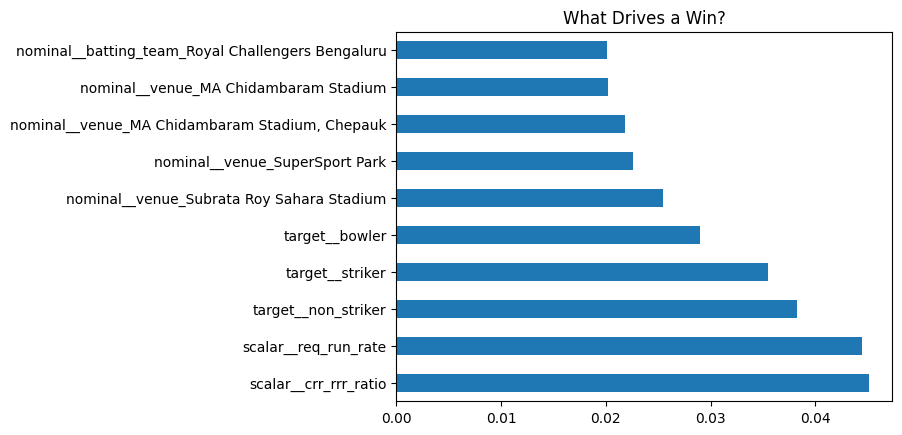

In [1224]:
import pandas as pd

xgb_model = best_estimator.named_steps['votingclassifier'].estimators_[2]
features = best_estimator.named_steps['columntransformer'].get_feature_names_out()

importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
importance.head(10).plot(kind='barh', title='What Drives a Win?')

In [1225]:
from xgboost import XGBClassifier

xgb_pipe = make_pipeline(
    preprocessing,
    XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_lambda=10,
        reg_alpha=5,
        min_child_weight=10,
        eval_metric='logloss'
    )
)
xgb_pipe.fit(x_train, y_train)

print("Train:", accuracy_score(y_train, xgb_pipe.predict(x_train)))
print("CV:   ", accuracy_score(y_cv,    xgb_pipe.predict(x_cv)))
print("Test: ", accuracy_score(y_test,  xgb_pipe.predict(x_test)))

Train: 0.8263192806603774
CV:    0.6998118178396688
Test:  0.764773015470454


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
